In [27]:
import os
import sys
import warnings

sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_preprocessing import preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Diabets](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [28]:
import kagglehub

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database") + "/diabetes.csv"

df = pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [29]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
le = LabelEncoder()
y = le.fit_transform(y)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y, shuffle=True)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=0, stratify=y_test, shuffle=True)

In [31]:
categorical_features = []
numerical_features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
column_transformer = ColumnTransformer([
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("scaling", StandardScaler(), numerical_features)
])

In [32]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-14 19:32:05,421] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-14 19:32:05,432] Trial 0 finished with value: 0.9051851851851851 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 0 with value: 0.9051851851851851.
[I 2025-04-14 19:32:05,438] Trial 1 finished with value: 0.8711111111111111 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.9051851851851851.
[I 2025-04-14 19:32:05,445] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 0 with value: 0.9051851851851851.
[I 2025-04-14 19:32:05,452] Trial 3 finished with value: 0.9059259259259258 and parameters: {'penalty': 'l2', 'C': 10}. Best is trial 3 with value: 0.9059259259259258.
[I 2025-04-14 19:32:05,458] Trial 4 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.001}. Best is trial 3 with value: 0.9059259259259258.
[I 2025-04-14 19:32:05,464] Trial 5 finished with value: 0.9059259259259258 and

ROC-AUC = 0.8667
F1 = 0.6531
Accuracy = 0.7792
Precision = 0.7273
Recall = 0.5926


In [33]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-14 19:32:05,577] A new study created in memory with name: catboost_optimization
[I 2025-04-14 19:32:05,889] Trial 0 finished with value: 0.882962962962963 and parameters: {'depth': 2, 'learning_rate': 0.3, 'l2_leaf_reg': 0.01}. Best is trial 0 with value: 0.882962962962963.
[I 2025-04-14 19:32:06,351] Trial 1 finished with value: 0.9125925925925926 and parameters: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 6.0}. Best is trial 1 with value: 0.9125925925925926.
[I 2025-04-14 19:32:09,098] Trial 2 finished with value: 0.8881481481481481 and parameters: {'depth': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 0.01}. Best is trial 1 with value: 0.9125925925925926.
[I 2025-04-14 19:32:10,239] Trial 3 finished with value: 0.9118518518518519 and parameters: {'depth': 8, 'learning_rate': 0.001, 'l2_leaf_reg': 0.01}. Best is trial 1 with value: 0.9125925925925926.
[I 2025-04-14 19:32:10,556] Trial 4 finished with value: 0.9044444444444444 and parameters: {'depth': 2, 'learning_rate'

ROC-AUC = 0.8319
F1 = 0.7059
Accuracy = 0.8052
Precision = 0.7500
Recall = 0.6667


In [34]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-14 19:32:26,247] A new study created in memory with name: lightgbm_optimization
[I 2025-04-14 19:32:27,953] Trial 0 finished with value: 0.8725925925925926 and parameters: {'num_leaves': 1024, 'reg_alpha': 0.1, 'reg_lambda': 1e-06, 'learning_rate': 0.03}. Best is trial 0 with value: 0.8725925925925926.
[I 2025-04-14 19:32:29,886] Trial 1 finished with value: 0.8792592592592593 and parameters: {'num_leaves': 512, 'reg_alpha': 0.01, 'reg_lambda': 1e-08, 'learning_rate': 0.03}. Best is trial 1 with value: 0.8792592592592593.
[I 2025-04-14 19:32:30,113] Trial 2 finished with value: 0.8996296296296296 and parameters: {'num_leaves': 4096, 'reg_alpha': 10.0, 'reg_lambda': 1e-06, 'learning_rate': 0.1}. Best is trial 2 with value: 0.8996296296296296.
[I 2025-04-14 19:32:30,701] Trial 3 finished with value: 0.8681481481481481 and parameters: {'num_leaves': 8, 'reg_alpha': 0.0001, 'reg_lambda': 1.0, 'learning_rate': 0.3}. Best is trial 2 with value: 0.8996296296296296.
[I 2025-04-14 19

ROC-AUC = 0.8107
F1 = 0.5957
Accuracy = 0.7532
Precision = 0.7000
Recall = 0.5185


In [35]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [36]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 128
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [37]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


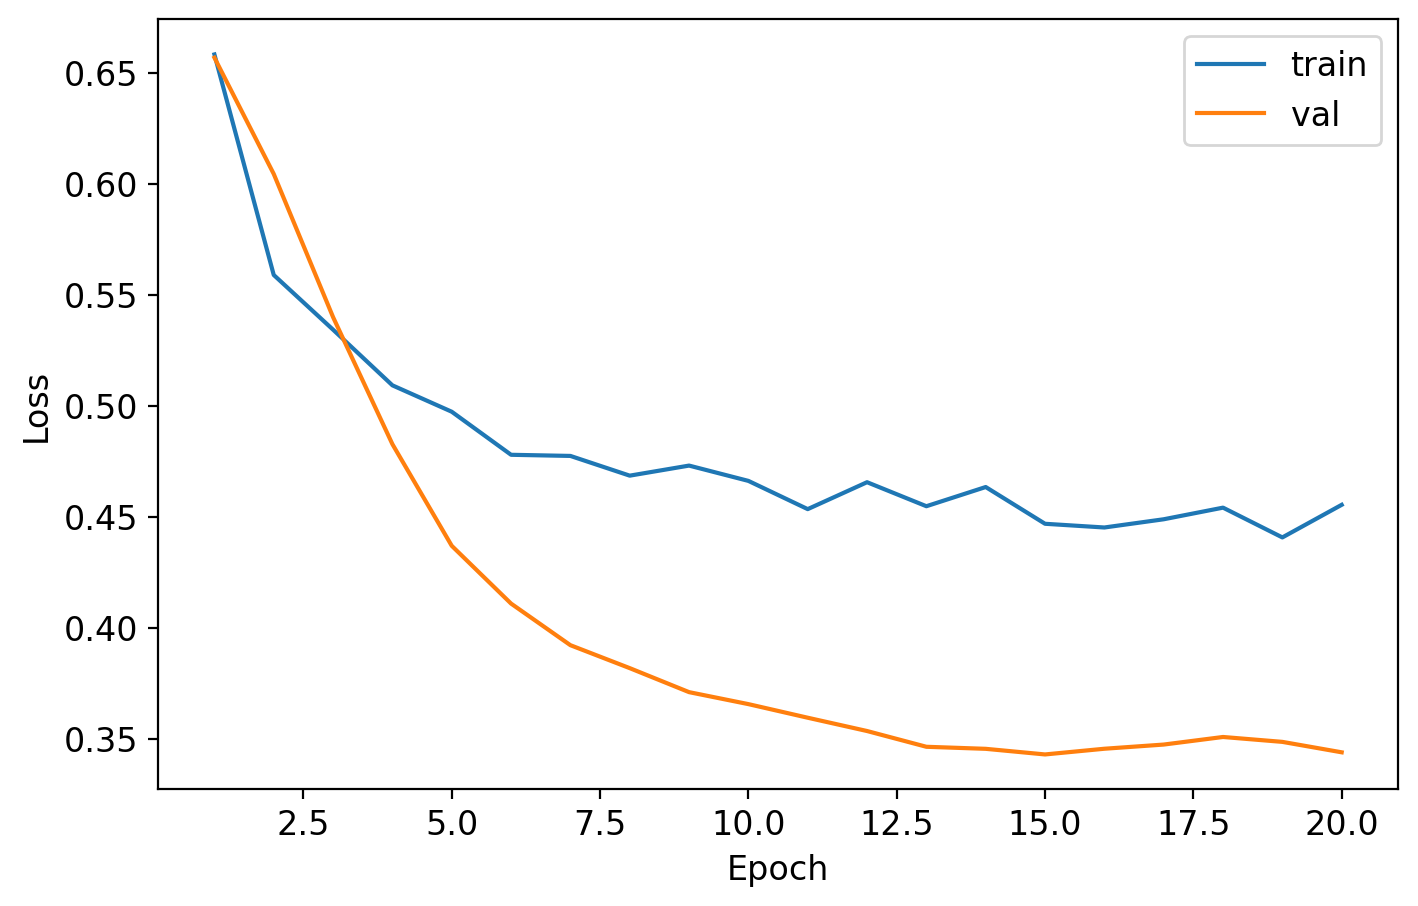

Epoch 20: train loss = 0.4554; valid loss = 0.3439


In [39]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [40]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.8622
F1 = 0.7200
Accuracy = 0.8182
Precision = 0.7826
Recall = 0.6667
